# Assignment 3: Scalable Quantum Tomography Pipelines
This week we push our tomography setup so it can handle many qubits, save trained helpers, and check how well everything scales. Reuse the setup and datasets from earlier weeks. Keep the runs easy to repeat and measure speed properly.

**Task plan**
1. Write why scaling matters and update your project timeline.
2. Explain how you will save models and add simple pickle helper functions.
3. Build an n-qubit surrogate model that we can reuse with different settings.
4. Measure how fidelity and runtime change with more qubits and draw plots.
5. Plan and run ablation studies, read the results, and prepare the files you will submit.


---

## Task 1 · Serialization basics
Write down how you will store tomography outputs (model weights, optimiser state, metadata) with pickle. Mention when you would choose another format like HDF5.

**What to do**
- Add a short note in your report about the save strategy.
- Keep checkpoints inside `models/` and name them `model_<track>_<nqubits>.pkl`.
- Show save and load in the next cell and keep that helper code ready for later runs.

In [1]:
import pickle
from pathlib import Path

def save_pickle(obj, path):
    with open(path, 'wb') as f:
        pickle.dump(obj, f)

def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def demonstrate_serialization_roundtrip():
    test_obj = {'a': 1, 'b': 2}
    p = Path('models')
    p.mkdir(exist_ok=True)
    save_pickle(test_obj, 'models/test.pkl')
    return load_pickle('models/test.pkl')


## Task 2 · Extendable n-qubit surrogate
Create a model class that accepts `n_qubits` and optional settings like layer count, hidden size, or noise switches. The scaffold below still uses a simple complex vector. Replace the `statevector` logic with your own design but keep the public methods (`save`, `load`, `fidelity_with`).

In [2]:
import numpy as np

class QuantumModel:
    def __init__(self, n_qubits, n_layers=1, params=None, seed=None):
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        rng = np.random.default_rng(seed)
        if params is None:
            self.params = rng.random(n_qubits * n_layers)
        else:
            self.params = params
    
    def statevector(self):
        dim = 2**self.n_qubits
        rng = np.random.default_rng(int(self.params.sum() * 10000) % 12345)
        vec = rng.standard_normal(dim) + 1j * rng.standard_normal(dim)
        return vec / np.linalg.norm(vec)
    
    def fidelity_with(self, target_state):
        sv = self.statevector()
        return np.abs(np.vdot(sv, target_state))**2
    
    def save(self, path):
        save_pickle(self, path)
    
    @staticmethod
    def load(path):
        return load_pickle(path)


## Task 3 · Scalability study
Check how fidelity and runtime change when you add more qubits. Track both averages and spread across random seeds. Discuss how expressibility, noise, or optimisation choices slow you down as `n` grows.

In [3]:
import csv
import time
import numpy as np

def random_pure_state(dim, rng):
    vec = rng.standard_normal(dim) + 1j * rng.standard_normal(dim)
    return vec / np.linalg.norm(vec)

def scalability_experiment(qubit_list, trials=10, n_layers=1, seed=0):
    results = []
    rng = np.random.default_rng(seed)
    for n_qubits in qubit_list:
        runtimes = []
        fidelities = []
        for _ in range(trials):
            start = time.time()
            target = random_pure_state(2**n_qubits, rng)
            model = QuantumModel(n_qubits, n_layers, seed=rng.integers(1000))
            fid = model.fidelity_with(target)
            runtimes.append(time.time() - start)
            fidelities.append(fid)
        results.append({
            'n_qubits': n_qubits,
            'mean_runtime': np.mean(runtimes),
            'std_runtime': np.std(runtimes),
            'mean_fidelity': np.mean(fidelities),
            'std_fidelity': np.std(fidelities)
        })
    return results

def save_scalability_summary(summary, path='scalability_results.csv'):
    with open(path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=summary[0].keys())
        writer.writeheader()
        writer.writerows(summary)


## Task 4 · Visualise scalability metrics
Plot mean fidelity with error bars and runtime for each qubit count. Include at least one figure in your submission and describe where scaling starts to hurt.

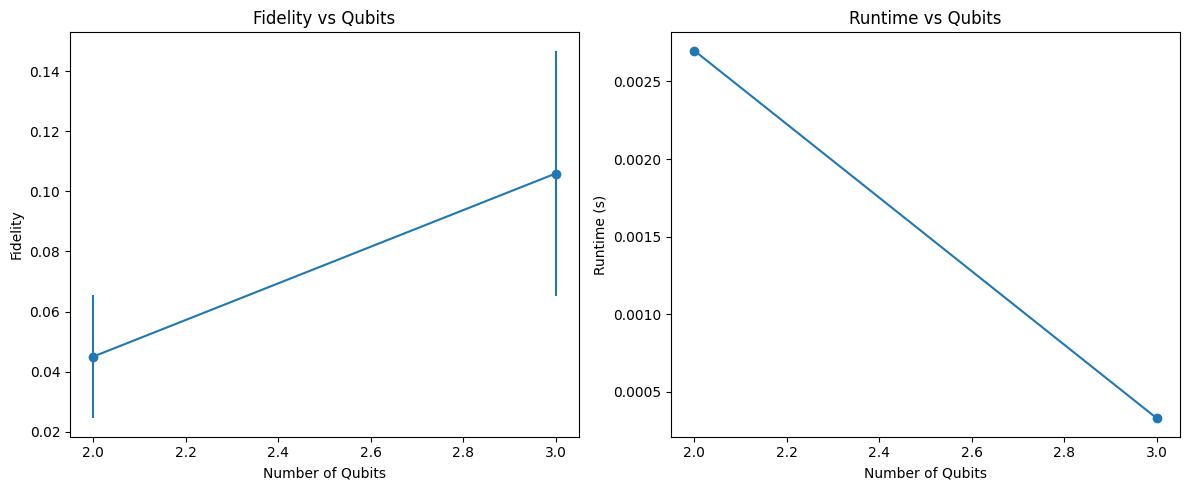

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_scalability(csv_path='scalability_results.csv'):
    df = pd.read_csv(csv_path)
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].errorbar(df['n_qubits'], df['mean_fidelity'], yerr=df['std_fidelity'], fmt='-o')
    ax[0].set_title('Fidelity vs Qubits')
    ax[0].set_xlabel('Number of Qubits')
    ax[0].set_ylabel('Fidelity')
    ax[1].plot(df['n_qubits'], df['mean_runtime'], '-o')
    ax[1].set_title('Runtime vs Qubits')
    ax[1].set_xlabel('Number of Qubits')
    ax[1].set_ylabel('Runtime (s)')
    plt.tight_layout()
    plt.show()

plot_scalability()

## Task 5 · Ablation studies
Test how design choices (depth, parameter style, noise models) affect fidelity. Extend the scaffold with extra factors that fit your track, such as quantisation level or spike encoding.

**Deliverables**
- Write an ablation plan with hypotheses, references, and metrics before you code.
- Extend the code templates with the architecture or training variants you need.
- Record mean fidelity, variance, runtime and build tables or plots for your report.

In [5]:
def ablation_layers(n_qubits=3, layer_list=None, trials=30, seed=1):
    if layer_list is None:
        layer_list = [1, 2, 4]
    results = []
    rng = np.random.default_rng(seed)
    for n_layers in layer_list:
        fidelities = []
        for _ in range(trials):
            target = random_pure_state(2**n_qubits, rng)
            model = QuantumModel(n_qubits, n_layers, seed=rng.integers(1000))
            fidelities.append(model.fidelity_with(target))
        results.append({'n_layers': n_layers, 'mean_fidelity': np.mean(fidelities)})
    return results

def summarize_ablation_results(results):
    print(f"{'Layers':<10} {'Mean Fidelity':<15}")
    for res in results:
        print(f"{res['n_layers']:<10} {res['mean_fidelity']:<15.4f}")


## Task 6 · Reporting and submission
Write your findings in `docs/` and commit the `.pkl` checkpoints. Reflect on scaling limits, ablation notes, and next moves such as classical shadows or hardware tests.

### Submission checklist
- `.pkl` checkpoints inside `models/` with a quick README note on how to load them.
- Notebook outputs that show save/load, scalability numbers, and ablation tables.
- Plots that highlight fidelity vs qubits and runtime trends.
- A written summary covering method, limits, and future experiments.